#**Predicting Customer Churn and Optimizing Bundling Strategies in the Telecom Industry Using Machine Learning**

> ## **Data Preprocessing**

### Step 1: Import libraries

In [ ]:
import pandas as pd #dataframe
import numpy as np #numerical operation
import matplotlib.pyplot as plt #basic visualisation
import seaborn as sns #statistical data visualisation

### Step 2: Load dataset

In [ ]:
telco = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') #load dataset

print(telco.head()) #print first 5 rows of the dataset
print(telco.info()) #summary of the dataset’s structure
print(telco.describe()) #statistical summaries
print(telco.isnull().sum())  # Explicit null check

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

> Initial Data Inspection
- Loaded the dataset (7,043 rows × 21 columns)
- Checked structure, basic statistics, and missing values

### Step 3: Handling Missing Values in the Dataset

Step 3A: Replace Blank Strings with NaN

In [ ]:
telco.replace(' ', pd.NA, inplace=True) #replace blank strings with NaN

Step 3B: Detect Missing Values

In [ ]:
missing_counts = telco.isna().sum() #count missing values
missing_counts = missing_counts[missing_counts > 0] #filters only columns have missing values

missing_percent = (telco.isna().sum() / len(telco)) * 100 #calculate missing value percentages
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False) #filter and sorts columns

print("Missing value counts:\n", missing_counts) #display results
print("\nMissing value percentages:\n", missing_percent)

Missing value counts:
 TotalCharges    11
dtype: int64

Missing value percentages:
 TotalCharges    0.156183
dtype: float64


Step 3C: Clean and Convert Data

In [ ]:
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce') #convert TotalCharges to numeric

telco.dropna(subset=['TotalCharges'], inplace=True) #removes rows where TotalCharges is missing

telco.reset_index(drop=True, inplace=True) #resets dataframe index

> Handling Missing Values
- Replaced blanks with NaN
- `TotalCharges` was converted to numeric
- Dropped ~11 rows with missing values (only 0.15%)
- Reset index to keep data consistent

### Step 4: Explore Target Class Distribution

Churn Value Counts:
 Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage Distribution:
 Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


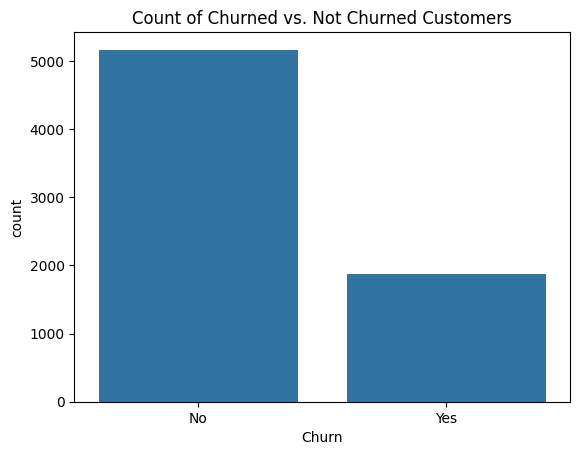

In [ ]:
#churn distribution: class imbalance
print("Churn Value Counts:\n", telco['Churn'].value_counts()) #counts how many customers churned vs. stayed
print("\nChurn Percentage Distribution:\n", telco['Churn'].value_counts(normalize=True) * 100) #calculates percentage distribution of churn values

sns.countplot(data=telco, x='Churn')
plt.title('Count of Churned vs. Not Churned Customers')
plt.show()

> Churn Distribution (Class Imbalance)
- About 73% of customers stayed, 27% churned
- This imbalance may bias the model, so handling class imbalance is important


### Step 5: Drop Irrelevant Columns

In [ ]:
telco.drop('customerID', axis=1, inplace=True) #remove customerID since it's not a predictive feature

> Drop Irrelevant Column
- Removed `customerID` as it’s a unique identifier, not useful for prediction

###Step 6: Identify Categorical Columns (for Encoding Later)

In [ ]:
categorical_cols = telco.select_dtypes(include='object').columns.tolist() #display all categorical columns
print("Categorical Columns:\n", categorical_cols)

Categorical Columns:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


> Identify Categorical Columns
- Selected all columns with `object` data type
- These columns were later encoded into numerical format for modeling

### Step 7: Encode Target Variable (Churn)

In [ ]:
#convert Churn to binary: Yes → 1, No → 0
telco['Churn'] = telco['Churn'].map({'Yes': 1, 'No': 0})

> Encode Target Variable
- Converted `Churn`: 'Yes' → 1, 'No' → 0
- Required for classification models

### Step 8: Encode Categorical Features

In [ ]:
#one-hot encode remaining categorical variables (drop first to avoid multicollinearity)
telco = pd.get_dummies(telco, drop_first=True)

> One-Hot Encoding
- Applied one-hot encoding to all remaining categorical columns
- Used `drop_first=True` to prevent multicollinearity
- Final dataset now contains only numeric features

### Step 9: Define Features and Target Variable

In [ ]:
#define X (features) and y (target)
X = telco.drop('Churn', axis=1)
y = telco['Churn']

> Feature and Target Separation
- `X`: all predictor features
- `y`: target variable (`Churn`)

### Step 10: Train-Test Split & Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

> Train-Test Split & Feature Scaling
- Split data into 80% training and 20% testing
- Scaled features using `StandardScaler` for uniformity

##**Model 1A: Random Forest Classifier (Without balancing)**

Random Forest (No Balance) - Accuracy: 0.7853589196872779
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

Random Forest (No Balance) F1 Score: 0.541033434650456
Confusion Matrix:
[[927 106]
 [196 178]]


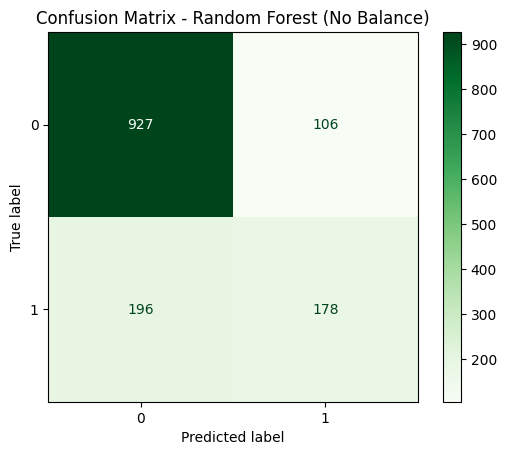

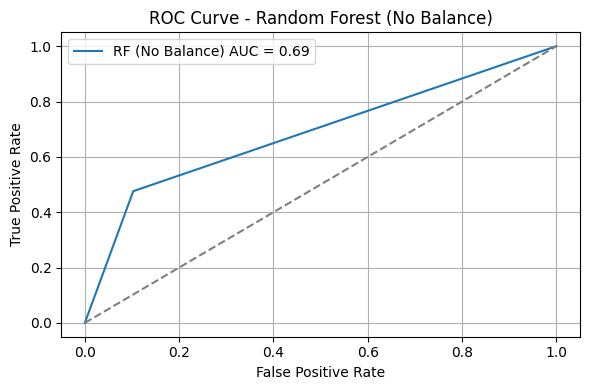

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve, auc

#train Random Forest without class balancing
rf_no_bal = RandomForestClassifier(random_state=42)
rf_no_bal.fit(X_train, y_train)

y_pred_rf_no = rf_no_bal.predict(X_test) #predict

#evaluate
print("Random Forest (No Balance) - Accuracy:", accuracy_score(y_test, y_pred_rf_no))
print(classification_report(y_test, y_pred_rf_no))
f1_rf_no = f1_score(y_test, y_pred_rf_no)
print("Random Forest (No Balance) F1 Score:", f1_rf_no)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_no)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_estimator(rf_no_bal, X_test, y_test, cmap='Greens')
plt.title("Confusion Matrix - Random Forest (No Balance)")
plt.show()

#compute ROC curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_no)
auc_rf = auc(fpr_rf, tpr_rf)

#plot
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f'RF (No Balance) AUC = {auc_rf:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Random Forest (No Balance)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

> Model 1A: Random Forest (No Balance)
- Accuracy: 78.5%
- F1 Score (Churn class): 0.54
- ROC AUC: 0.69

> Confusion Matrix Insight:
- Predicted many non-churners correctly
- Missed 196 actual churners

> Conclusion:
- Model is affected by class imbalance
- Next: Try balancing or compare with Logistic Regression

##**Model 1B: Random Forest Classifier (Balanced with Hyperparameter Tuning - GridSearchCV)**

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Classification Report (Best Random Forest - Balanced):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.52      0.70      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

Best Random Forest (Balanced) F1 Score: 0.5965714285714285
Confusion Matrix:
[[793 240]
 [113 261]]


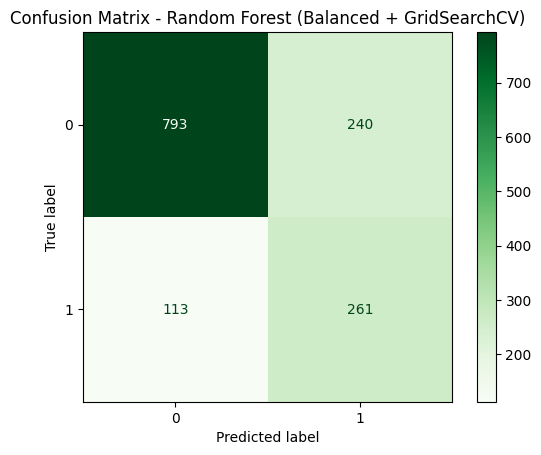

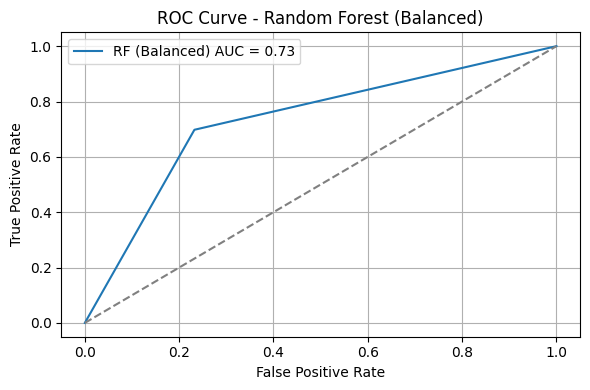

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_bal = RandomForestClassifier(class_weight='balanced', random_state=42) #class weight

#hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

#GridSearchCV with F1-score
grid_rf = GridSearchCV(rf_bal, param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

#best model from grid search
best_rf_bal = grid_rf.best_estimator_
y_pred_rf_bal = best_rf_bal.predict(X_test)

#evaluation
print("Best Random Forest Parameters:", grid_rf.best_params_)
print("\nClassification Report (Best Random Forest - Balanced):")
print(classification_report(y_test, y_pred_rf_bal))
f1_rf_bal = f1_score(y_test, y_pred_rf_bal)
print("Best Random Forest (Balanced) F1 Score:", f1_rf_bal)


#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_bal)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_estimator(best_rf_bal, X_test, y_test, cmap='Greens')
plt.title("Confusion Matrix - Random Forest (Balanced + GridSearchCV)")
plt.show()

#compute ROC curve and AUC
fpr_rf_bal, tpr_rf_bal, _ = roc_curve(y_test, y_pred_rf_bal)
auc_rf_bal = auc(fpr_rf_bal, tpr_rf_bal)

#plot
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_bal, tpr_rf_bal, label=f'RF (Balanced) AUC = {auc_rf_bal:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Random Forest (Balanced)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

> Model 1B: Random Forest (Balanced + GridSearchCV)
- Best Params: max_depth=10, min_samples_split=5, n_estimators=200
- Accuracy: 75%
- F1 Score (Churn): 0.60
- ROC AUC: 0.73

> Confusion Matrix Insight:
- Better at catching churners (70% recall)
- More balanced predictions overall

> Improvement:
- F1 Score and AUC higher than unbalanced model


Metric Comparison (Before vs After Balancing):

| Metric               | RF (No Balance) | RF (Balanced) |
| -------------------- | --------------- | ------------- |
| **F1 Score**         | 0.54            | 0.60 ✅        |
| **AUC Score**        | 0.69            | 0.73 ✅        |
| **Recall (Class 1)** | 0.48            | 0.70 ✅        |

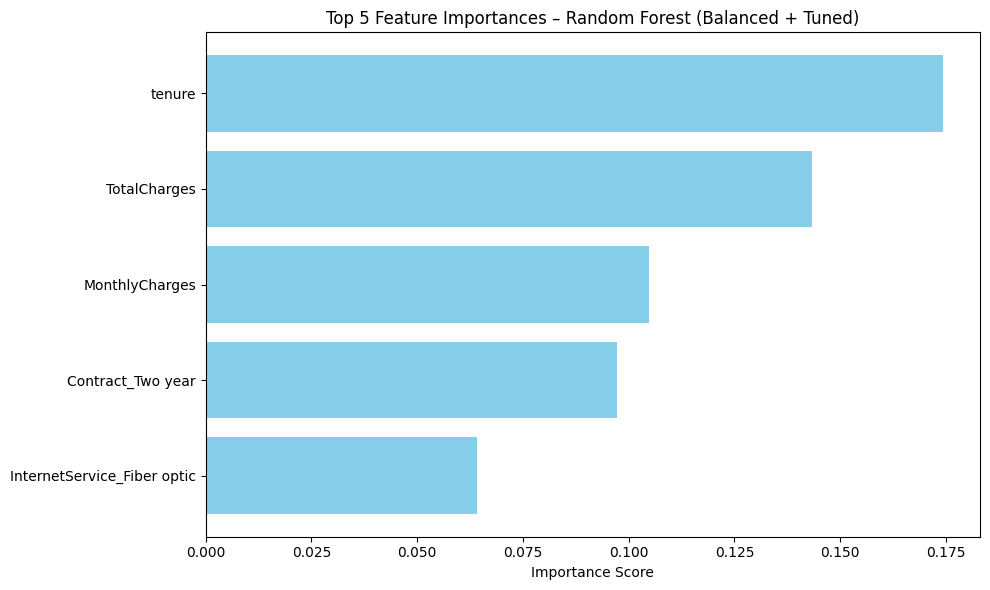

                        Feature  Importance
1                        tenure    0.174355
3                  TotalCharges    0.143457
2                MonthlyCharges    0.104810
25            Contract_Two year    0.097302
10  InternetService_Fiber optic    0.064240


In [ ]:
#extract feature importances from Random Forest
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_bal.feature_importances_
})

#sort by importance and take top 5
top_5 = importances.sort_values(by='Importance', ascending=False).head(5)

#plot top 5
plt.figure(figsize=(10, 6))
plt.barh(top_5['Feature'][::-1], top_5['Importance'][::-1], color='skyblue')
plt.xlabel("Importance Score")
plt.title("Top 5 Feature Importances – Random Forest (Balanced + Tuned)")
plt.tight_layout()
plt.show()

#display as table
print(top_5)

> **Top 5 Most Important Features (Random Forest)**
1. **Tenure** – customers with shorter tenure tend to churn more
2. **TotalCharges** – low lifetime spending may signal at-risk customers
3. **MonthlyCharges** – high monthly cost can increase churn risk
4. **Contract_Two year** – longer contracts reduce likelihood of churn
5. **InternetService_Fiber optic** – may be linked to dissatisfaction in service

> **Business Insight:**
- These features can help design targeted retention strategies (e.g. discount high monthly charges for short-tenure customers)


##**Model 2A: Logistic Regression (Without balancing)**

Logistic Regression (No Balancing) - Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Logistic Regression (No Balance) F1 Score: 0.5635036496350365
Confusion Matrix:
[[915 118]
 [181 193]]


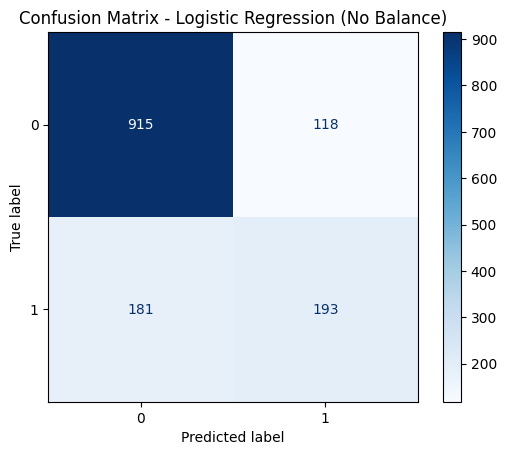

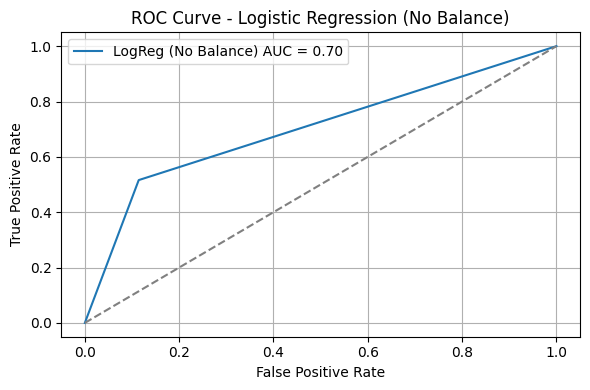

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve, auc

logreg_no_bal = LogisticRegression(max_iter=1000, random_state=42)
logreg_no_bal.fit(X_train_scaled, y_train)

#predictions
y_pred_no_bal = logreg_no_bal.predict(X_test_scaled)

#evaluation
print("Logistic Regression (No Balancing) - Accuracy:", accuracy_score(y_test, y_pred_no_bal))
print(classification_report(y_test, y_pred_no_bal))
f1_no_bal = f1_score(y_test, y_pred_no_bal)
print("Logistic Regression (No Balance) F1 Score:", f1_no_bal)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_no_bal)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_estimator(logreg_no_bal, X_test_scaled, y_test, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (No Balance)")
plt.show()

#compute ROC curve and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_no_bal)
auc_lr = auc(fpr_lr, tpr_lr)

#plot
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (No Balance) AUC = {auc_lr:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Logistic Regression (No Balance)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

> Logistic Regression (No Balancing)
- Accuracy: 78.7%
- F1 Score (Churn): 0.56
- AUC: 0.70

> Confusion Matrix Insight:
- Still misclassifies many churners
- Similar issue as unbalanced Random Forest

## **Model 2B: Logistic Regression (Balanced with Hyperparameter Tuning - GridSearchCV)**

Best Parameters (Balanced Logistic Regression): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

Balanced Logistic Regression F1 Score: 0.6086956521739131
Confusion Matrix:
[[735 298]
 [ 80 294]]


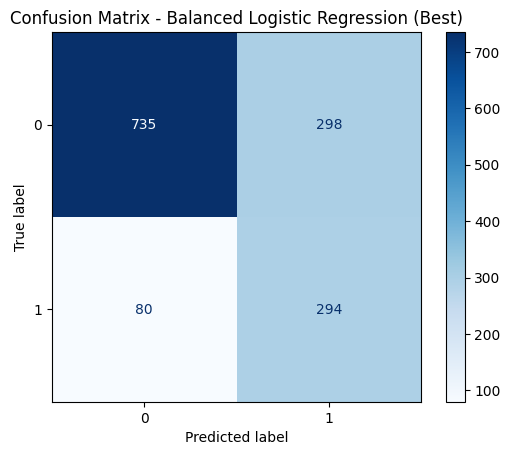

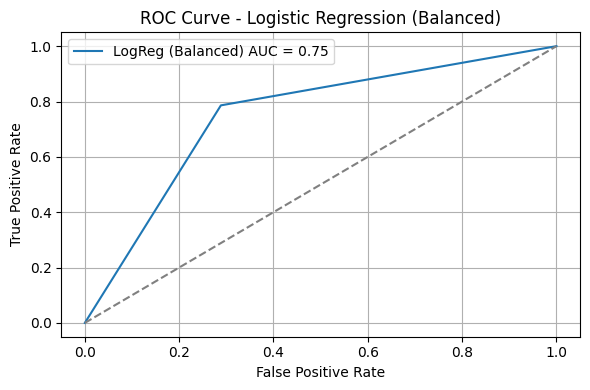

In [ ]:
from sklearn.model_selection import GridSearchCV

logreg_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(logreg_bal, param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)

best_lr_bal = grid_lr.best_estimator_
y_pred_lr_bal = best_lr_bal.predict(X_test_scaled)

#evaluation
print("Best Parameters (Balanced Logistic Regression):", grid_lr.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_bal))
f1_lr = f1_score(y_test, y_pred_lr_bal)
print("Balanced Logistic Regression F1 Score:", f1_lr)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_bal)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_estimator(best_lr_bal, X_test_scaled, y_test, cmap='Blues')
plt.title("Confusion Matrix - Balanced Logistic Regression (Best)")
plt.show()

#compute ROC curve and AUC
fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y_test, y_pred_lr_bal)
auc_lr_bal = auc(fpr_lr_bal, tpr_lr_bal)

#plot
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_bal, tpr_lr_bal, label=f'LogReg (Balanced) AUC = {auc_lr_bal:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Logistic Regression (Balanced)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

> Final Model: Logistic Regression (Balanced + GridSearchCV)
- Class weight balanced
- Tuned parameters:
  - `C`: regularization strength
  - `solver`: optimization algorithm
- Scored using F1 for churn class

> Outcome:
- Highest F1 score among all models
- Most balanced confusion matrix
- Best ROC AUC


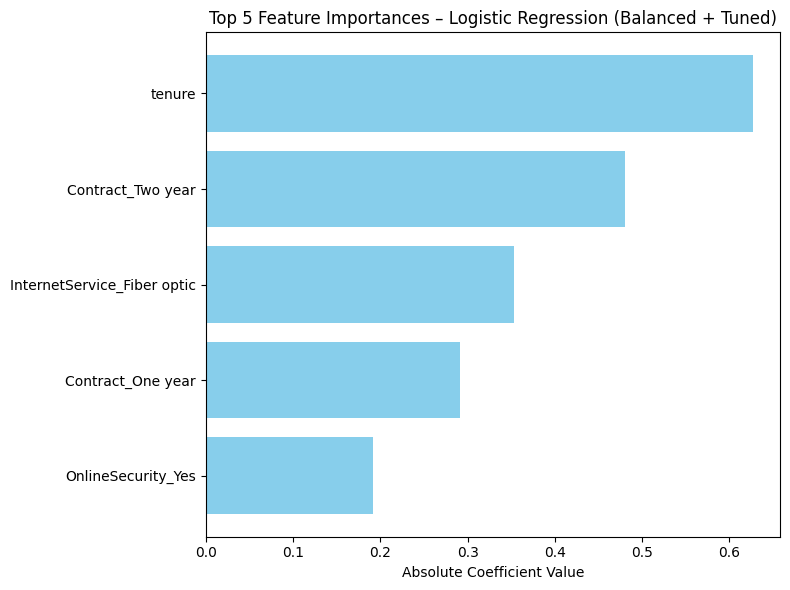

                        Feature  Coefficient        Direction
1                        tenure    -0.626568  Decreases churn
25            Contract_Two year    -0.480390  Decreases churn
10  InternetService_Fiber optic     0.353362  Increases churn
24            Contract_One year    -0.291575  Decreases churn
13           OnlineSecurity_Yes    -0.191599  Decreases churn


In [ ]:
#feature Importance – Logistic Regression
coefficients = best_lr_bal.coef_[0]  # For binary classification
features = X.columns

#create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(coefficients)
}).sort_values(by='Importance', ascending=True)

#select top 5 most important features
top_5 = importance_df.tail(5)

#plot
plt.figure(figsize=(8, 6))
plt.barh(top_5['Feature'], top_5['Importance'], color='skyblue')
plt.title("Top 5 Feature Importances – Logistic Regression (Balanced + Tuned)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()

#get coefficients and features
coefficients = best_lr_bal.coef_[0]
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})
importance_df['Direction'] = np.where(importance_df['Coefficient'] > 0, 'Increases churn', 'Decreases churn')
importance_df['Importance'] = np.abs(importance_df['Coefficient'])

#get top 5
top5 = importance_df.sort_values(by='Importance', ascending=False).head(5)
print(top5[['Feature', 'Coefficient', 'Direction']])

> **Logistic Regression – Top 5 Features**

| Feature                  | Impact             |
|--------------------------|--------------------|
| Tenure                   | Longer tenure → lower churn
| Contract_Two year        | Long contract → lower churn
| InternetService_Fiber    | Using fiber → higher churn
| Contract_One year        | Medium contract → still lowers churn
| OnlineSecurity_Yes       | Security addon → reduces churn

> **Business Insight:**
- Offer better support to fiber users
- Reward short-tenure customers with contract upgrades
- Promote security packages to reduce churn